In [1]:
import numpy as np #linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns #For creating plots
import matplotlib.ticker as mtick # For specifying the axes tick format
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
telecom_cust=pd.read_csv('Telco_Customer_Churn.csv')

In [3]:
pd.set_option("display.max_columns", 100)

In [4]:
telecom_cust.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
telecom_cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
telecom_cust.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
telecom_cust.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [8]:
telecom_cust.TotalCharges=pd.to_numeric(telecom_cust.TotalCharges, errors='coerce')

In [9]:
telecom_cust.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
#Data is right skewed, hence we can fill them with median
telecom_cust.TotalCharges = telecom_cust.TotalCharges.fillna(telecom_cust.TotalCharges.median())

In [11]:
telecom_cust.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df2=telecom_cust.drop(['customerID'], axis=1)

In [13]:
df2['Churn'].replace(to_replace='Yes', value=1, inplace=True)
df2['Churn'].replace(to_replace='No', value=0, inplace=True)

In [14]:
df_dummies = pd.get_dummies(df2, drop_first=True)
df_dummies.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


<Axes: >

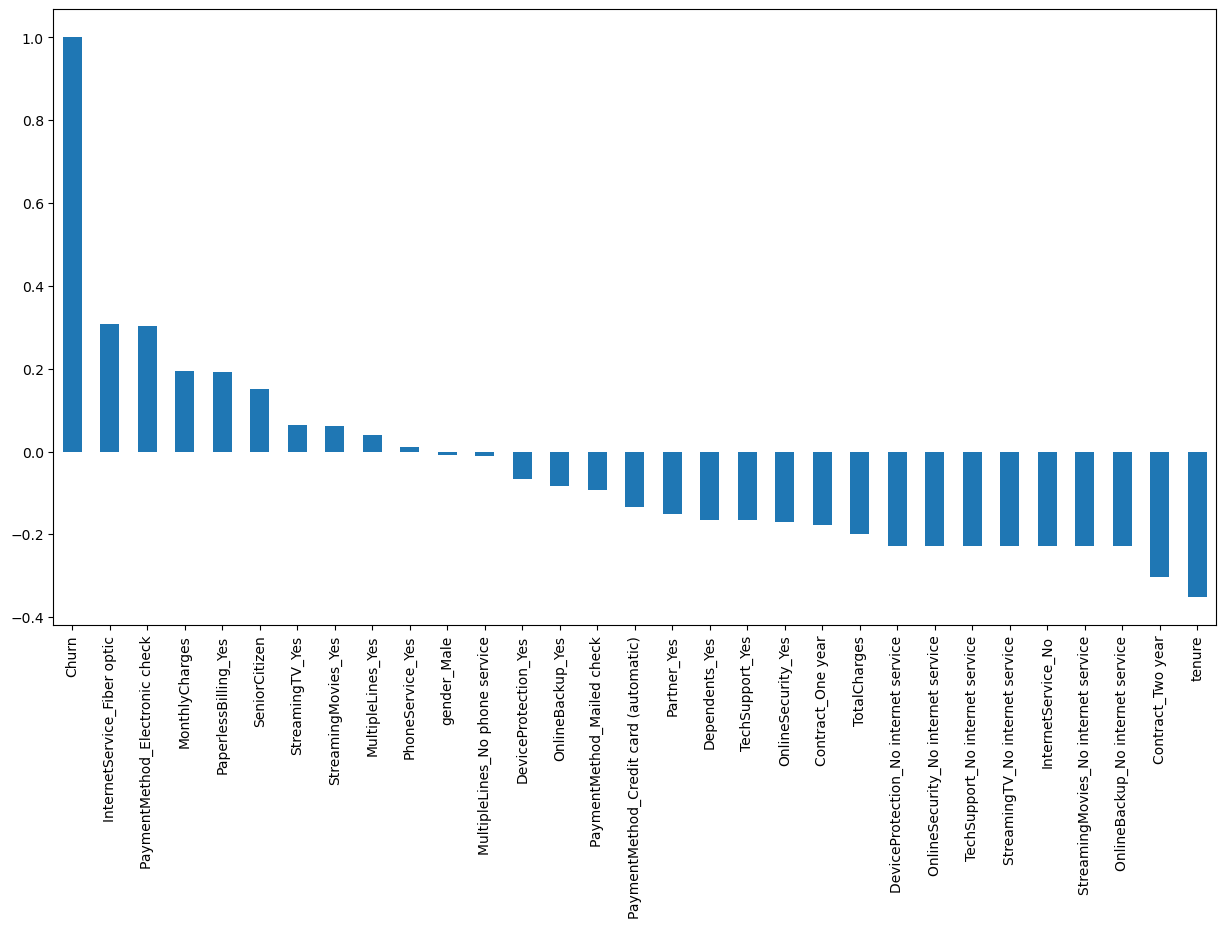

In [15]:
#Get Correlation of "Churn" with other variables
plt.figure(figsize=(15, 8))
df_dummies.corr()['Churn'].sort_values(ascending=False).plot(kind='bar')

gender
Male      0.504756
Female    0.495244
Name: proportion, dtype: float64

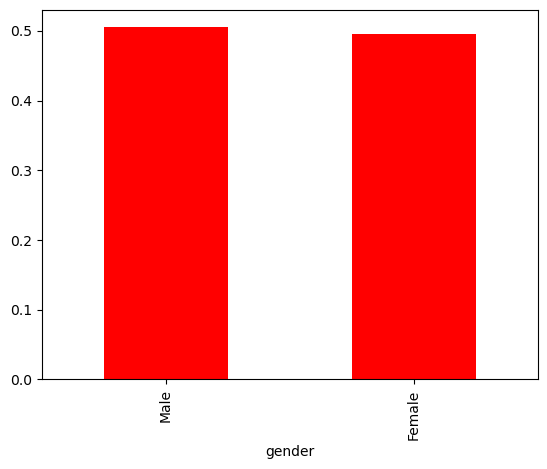

In [16]:
telecom_cust['gender'].value_counts(normalize=True).plot.bar(color='red')
telecom_cust['gender'].value_counts(normalize=True)

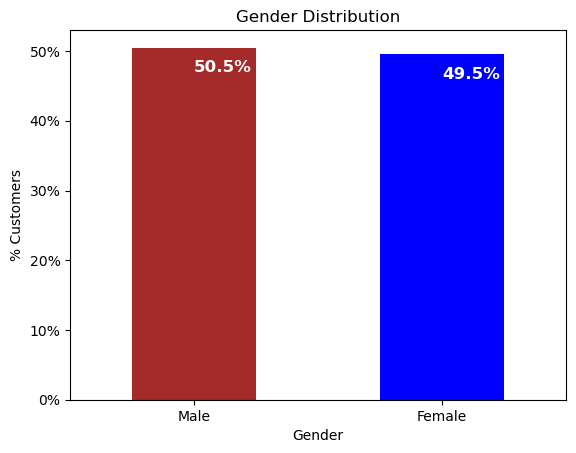

In [17]:
colors=['brown','blue']
gender_counts=telecom_cust['gender'].value_counts()
ax=(gender_counts*100.0/len(telecom_cust)).plot(
    kind='bar',
    stacked=True,
    rot=0,
    color=colors
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('% Customers')
ax.set_xlabel('Gender')
ax.set_title('Gender Distribution')

#Iterate over the bar heights and add labels to the bars
total=gender_counts.sum()
for bar, count in zip(ax.patches, gender_counts):
    percentage=count/total*100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()-3.5,
            f'{percentage:.1f}%',
            fontsize=12,
            color='white',
            weight='bold'
          )

Text(0.5, 1.0, '% of Senior Citizens')

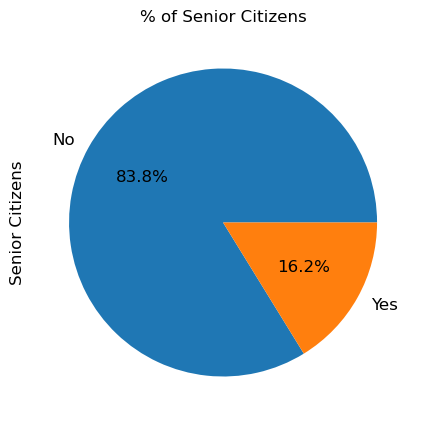

In [18]:
ax=(telecom_cust['SeniorCitizen'].value_counts()*100.0/len(telecom_cust))\
.plot.pie(autopct='%.1f%%', labels=['No','Yes'], figsize=(5, 5), fontsize=12)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('Senior Citizens', fontsize=12)
ax.set_title('% of Senior Citizens', fontsize=12)

Text(0.5, 1.0, 'No of Customers by their tenure')

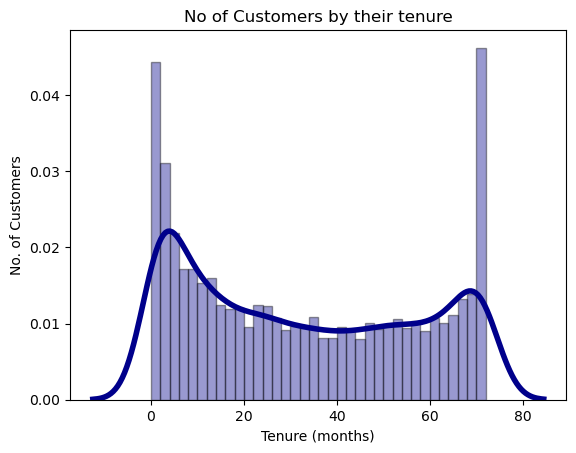

In [19]:
ax=sns.distplot(telecom_cust['tenure'], hist=True, kde=True,
                bins=int(180/5), color='darkblue',
                hist_kws={'edgecolor':'black'},
                kde_kws={'linewidth':4})
ax.set_ylabel('No. of Customers')
ax.set_xlabel('Tenure (months)')
ax.set_title('No of Customers by their tenure')

Text(0.5, 1.0, 'No. of Customers by Contract Type')

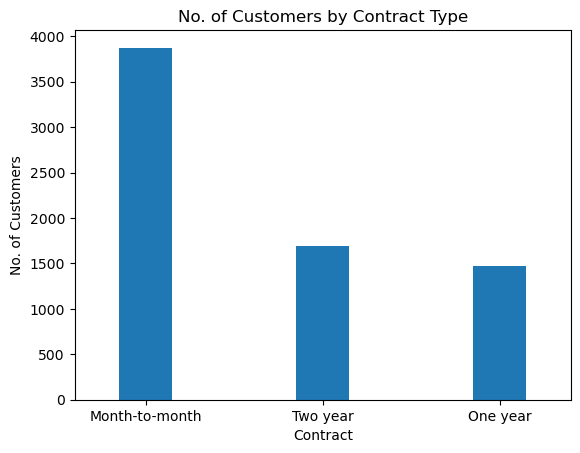

In [20]:
ax=telecom_cust['Contract'].value_counts().plot(kind='bar', rot=0, width=0.3)
ax.set_ylabel('No. of Customers')
ax.set_title('No. of Customers by Contract Type')

In [21]:
y=df_dummies['Churn'].values
X=df_dummies.drop(columns=['Churn'])

from sklearn.preprocessing import MinMaxScaler

features=X.columns.values
scaler=MinMaxScaler(feature_range=(0, 1))
scaler.fit(X)
X=pd.DataFrame(scaler.transform(X))
X.columns=features

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.3, random_state=101)

In [23]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
result=model.fit(X_train, y_train)

In [24]:
from sklearn import metrics
prediction_test=model.predict(X_test)

print(metrics.accuracy_score(y_test, prediction_test))

0.8050165641268339


Axes(0.125,0.11;0.775x0.77)


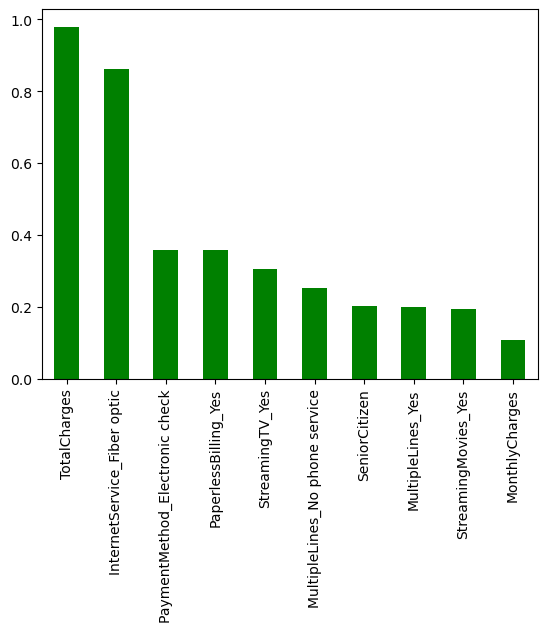

In [25]:
weights=pd.Series(model.coef_[0], index=X.columns.values)
print(weights.sort_values(ascending=False)[:10].plot(kind='bar', color='green'))

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2,random_state=101)
model_rf=RandomForestClassifier(n_estimators=1000, oob_score=True, n_jobs=-1, random_state=50, max_leaf_nodes=30)
model_rf.fit(X_train, y_train)

prediction_test=model_rf.predict(X_test)
print(metrics.accuracy_score(y_test, prediction_test))

0.801277501774308


<Axes: >

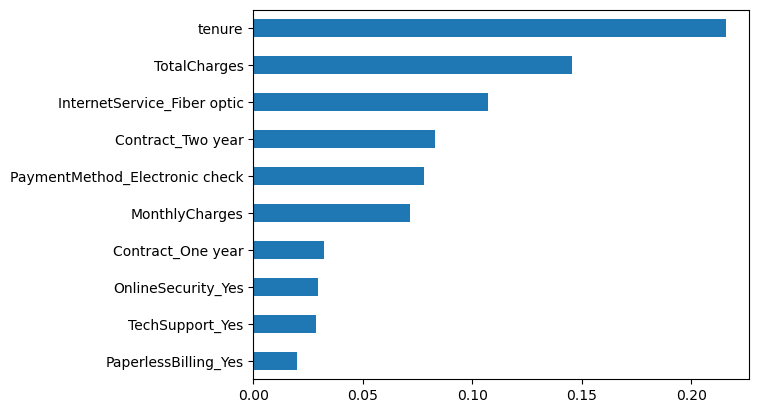

In [29]:
importances=model_rf.feature_importances_
weights=pd.Series(importances, index=X.columns.values)
weights.sort_values()[-10:].plot(kind='barh')